# EQRM Extension Experiments: Extended MNIST Benchmarks

This notebook runs the full experimental sweep for the EQRM paper extension,
covering:

1. **ColoredMNIST multi-domain** — Testing quantile convergence (Thm 4.1)
2. **RotatedMNIST** — First evaluation on a theoretically-discussed benchmark
3. **ColoredFashionMNIST** — Harder invariant features

All results are saved to Google Drive and comprehensive plots are generated.

## 0. Setup

In [1]:
import sys
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive (for reading code + saving results)
drive.mount('/content/drive')

# 2. Source on Drive, destination on local Colab disk
DRIVE_ROOT = '/content/drive/MyDrive/IFT6168/qrm/DomainBed/'
LOCAL_ROOT = '/content/DomainBed/'

# 3. Copy DomainBed code to local disk (first time only, ~30s-1min)
if not os.path.exists(LOCAL_ROOT):
    print("Copying DomainBed to local disk (one-time, ~30-60s)...")
    shutil.copytree(DRIVE_ROOT, LOCAL_ROOT)
    print("Done.")
else:
    print("Local copy already exists.")

# 4. Work from the LOCAL copy
PROJECT_ROOT = LOCAL_ROOT
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

%cd {PROJECT_ROOT}

# 5. Install dependencies
!pip install -q -r domainbed/requirements.txt

# 6. Results still go to Drive (so they persist after Colab session ends)
RESULTS_DIR = '/content/drive/MyDrive/IFT6168/qrm/results/'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'plots'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'raw'), exist_ok=True)

print(f"Code dir (fast):    {os.getcwd()}")
print(f"Results dir (Drive): {RESULTS_DIR}")

Mounted at /content/drive
Copying DomainBed to local disk (one-time, ~30-60s)...
Done.
/content/DomainBed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.6/196.6 kB 19.5 MB/s eta 0:00:00
Code dir (fast):    /content/DomainBed
Results dir (Drive): /content/drive/MyDrive/IFT6168/qrm/results/


In [2]:
# Verify extended datasets are loadable
from domainbed import datasets

NEW_DATASETS = [
    'ColoredMNIST5', 'ColoredMNIST10', 'ColoredMNIST20',
    'ColoredMNISTContinuous',
    'RotatedMNIST12', 'RotatedMNIST18', 'RotatedMNIST36',
    'RotatedMNISTNonUniform',
    'ColoredFashionMNIST', 'ColoredFashionMNIST10',
]

for name in NEW_DATASETS:
    cls = datasets.get_dataset_class(name)
    print(f"{name}: {len(cls.ENVIRONMENTS)} environments — {cls.ENVIRONMENTS}")

print("\nAll new datasets loaded successfully!")

ColoredMNIST5: 5 environments — ['e0.05', 'e0.18', 'e0.32', 'e0.45', 'e0.90']
ColoredMNIST10: 10 environments — ['e0.05', 'e0.10', 'e0.15', 'e0.20', 'e0.25', 'e0.30', 'e0.35', 'e0.40', 'e0.45', 'e0.90']
ColoredMNIST20: 20 environments — ['e0.05', 'e0.07', 'e0.09', 'e0.12', 'e0.14', 'e0.16', 'e0.18', 'e0.21', 'e0.23', 'e0.25', 'e0.27', 'e0.29', 'e0.32', 'e0.34', 'e0.36', 'e0.38', 'e0.41', 'e0.43', 'e0.45', 'e0.90']
ColoredMNISTContinuous: 10 environments — ['fp0', 'fp1', 'fp2', 'fp3', 'fp4', 'fp5', 'fp6', 'fp7', 'fp8', 'fp9']
RotatedMNIST12: 12 environments — ['0', '15', '30', '45', '60', '75', '90', '105', '120', '135', '150', '165']
RotatedMNIST18: 18 environments — ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100', '110', '120', '130', '140', '150', '160', '170']
RotatedMNIST36: 36 environments — ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100', '110', '120', '130', '140', '150', '160', '170', '180', '190', '200', '210', '220', '230', '240', '250', '2

## 1. Experiment Runner

We define a helper that runs `domainbed.scripts.train` as a subprocess and
collects the JSON results. This avoids issues with global state across runs.

In [3]:
import subprocess
import json
import time
import glob
import pandas as pd
import numpy as np
from pathlib import Path


def run_single_experiment(dataset, algorithm, test_env, hparams_seed=0,
                          trial_seed=0, steps=None, hparams=None,
                          data_dir='./domainbed/data/MNIST/'):
    """Run a single DomainBed training run and return the output directory."""
    output_dir = os.path.join(
        RESULTS_DIR, 'raw',
        f'{dataset}_{algorithm}_te{test_env}_hs{hparams_seed}_ts{trial_seed}'
    )
    os.makedirs(output_dir, exist_ok=True)

    # Check if already completed
    done_file = os.path.join(output_dir, 'done')
    if os.path.exists(done_file):
        print(f"  [SKIP] Already done: {dataset}/{algorithm}/te{test_env}")
        return output_dir

    cmd = [
        'python3', '-m', 'domainbed.scripts.train',
        '--data_dir', data_dir,
        '--output_dir', output_dir,
        '--algorithm', algorithm,
        '--dataset', dataset,
        '--test_env', str(test_env),
        '--hparams_seed', str(hparams_seed),
        '--trial_seed', str(trial_seed),
        '--skip_model_save',
    ]

    if steps is not None:
        cmd += ['--steps', str(steps)]

    if hparams is not None:
        cmd += ['--hparams', json.dumps(hparams)]

    print(f"  [RUN] {dataset} / {algorithm} / test_env={test_env} / "
          f"hs={hparams_seed} ts={trial_seed}")

    t0 = time.time()
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=PROJECT_ROOT)
    elapsed = time.time() - t0

    if result.returncode != 0:
        print(f"  [FAIL] ({elapsed:.0f}s) stderr: {result.stderr[-500:]}")
        return None

    print(f"  [DONE] ({elapsed:.0f}s)")
    return output_dir


def parse_results_jsonl(output_dir):
    """Parse the results.jsonl file from a DomainBed run."""
    results_file = os.path.join(output_dir, 'results.jsonl')
    if not os.path.exists(results_file):
        return None

    records = []
    with open(results_file, 'r') as f:
        for line in f:
            records.append(json.loads(line.strip()))

    if not records:
        return None

    # Return the last record (final checkpoint)
    return records[-1]


def collect_all_results(base_dir):
    """Collect results from all experiment subdirectories."""
    rows = []
    raw_dir = os.path.join(base_dir, 'raw')
    if not os.path.exists(raw_dir):
        return pd.DataFrame()

    for subdir in sorted(os.listdir(raw_dir)):
        full_path = os.path.join(raw_dir, subdir)
        if not os.path.isdir(full_path):
            continue

        result = parse_results_jsonl(full_path)
        if result is None:
            continue

        # Parse the directory name for metadata
        args_file = os.path.join(full_path, 'args.json')
        if os.path.exists(args_file):
            with open(args_file) as f:
                args = json.loads(f.read())
        else:
            args = {}

        row = {
            'dataset': args.get('dataset', ''),
            'algorithm': args.get('algorithm', ''),
            'test_env': str(args.get('test_envs', '')),
            'hparams_seed': args.get('hparams_seed', 0),
            'trial_seed': args.get('trial_seed', 0),
            'step': result.get('step', 0),
        }

        # Extract per-environment accuracies
        for key, val in result.items():
            if key.startswith('env') and '_' in key:
                row[key] = val

        rows.append(row)

    return pd.DataFrame(rows)

## 2. Experiment Sweep Configuration

We define three experiment blocks:
- **Block A**: ColoredMNIST domain scaling (tests Thm 4.1 convergence)
- **Block B**: RotatedMNIST (first evaluation, quantile risk analysis)
- **Block C**: ColoredFashionMNIST (harder invariant features)

In [4]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================
# Adjust N_TRIALS, N_HPARAMS, and STEPS to fit your compute budget.
#
# Conservative (fast, ~2-3 hours on Colab GPU):
#   N_TRIALS = 1, N_HPARAMS = 3, STEPS = 3001
#
# Full (thorough, ~10-15 hours):
#   N_TRIALS = 3, N_HPARAMS = 5, STEPS = 5001

N_TRIALS = 1
N_HPARAMS = 1
STEPS_SMALL = 5001       # For datasets with <=10 domains
STEPS_LARGE = 8001       # For datasets with >10 domains

ALGORITHMS = ['ERM', 'EQRM', 'VREx', 'IRM', 'GroupDRO']

# Block A: ColoredMNIST domain scaling
BLOCK_A = {
    'name': 'ColoredMNIST Domain Scaling',
    'datasets': [
        ('ColoredMNIST',   './domainbed/data/MNIST/', 2, STEPS_SMALL),   # test_env = last
        ('ColoredMNIST5',  './domainbed/data/MNIST/', 4, STEPS_SMALL),
        ('ColoredMNIST10', './domainbed/data/MNIST/', 9, STEPS_SMALL),
        #('ColoredMNIST20', './domainbed/data/MNIST/', 19, STEPS_LARGE),
    ],
    'algorithms': ALGORITHMS,
}

# Block B: RotatedMNIST variants
BLOCK_B = {
    'name': 'RotatedMNIST Evaluation',
    'datasets': [
        ('RotatedMNIST',   './domainbed/data/MNIST/', [5], STEPS_SMALL),
        ('RotatedMNIST12', './domainbed/data/MNIST/', [6], STEPS_SMALL),
        ('RotatedMNIST18', './domainbed/data/MNIST/', [9], STEPS_SMALL),
    ],
    'algorithms': ['ERM', 'EQRM', 'VREx', 'GroupDRO'],
}

# Block C: Fashion MNIST comparison
BLOCK_C = {
    'name': 'ColoredFashionMNIST',
    'datasets': [
        ('ColoredMNIST',        './domainbed/data/MNIST/', 2, STEPS_SMALL),
        ('ColoredFashionMNIST', './domainbed/data/',       2, STEPS_SMALL),
        ('ColoredMNIST10',      './domainbed/data/MNIST/', 9, STEPS_SMALL),
        ('ColoredFashionMNIST10','./domainbed/data/',      9, STEPS_SMALL),
    ],
    'algorithms': ['ERM', 'EQRM', 'VREx', 'IRM'],
}

print("Experiment blocks configured.")
print(f"  Trials per config: {N_TRIALS}")
print(f"  Hparam seeds: {N_HPARAMS}")

Experiment blocks configured.
  Trials per config: 1
  Hparam seeds: 1


## 3. Run Block A — ColoredMNIST Domain Scaling

In [6]:
print("=" * 70)
print("BLOCK A: ColoredMNIST Domain Scaling")
print("=" * 70)

for dataset_name, data_dir, test_env, steps in BLOCK_A['datasets']:
    for algo in BLOCK_A['algorithms']:
        for hs in range(N_HPARAMS):
            for ts in range(N_TRIALS):
                run_single_experiment(
                    dataset=dataset_name,
                    algorithm=algo,
                    test_env=test_env,
                    hparams_seed=hs,
                    trial_seed=ts,
                    steps=steps,
                    data_dir=data_dir,
                )

print("\nBlock A complete.")

BLOCK A: ColoredMNIST Domain Scaling
  [SKIP] Already done: ColoredMNIST/ERM/te2
  [SKIP] Already done: ColoredMNIST/EQRM/te2
  [SKIP] Already done: ColoredMNIST/VREx/te2
  [SKIP] Already done: ColoredMNIST/IRM/te2
  [SKIP] Already done: ColoredMNIST/GroupDRO/te2
  [SKIP] Already done: ColoredMNIST5/ERM/te4
  [SKIP] Already done: ColoredMNIST5/EQRM/te4
  [SKIP] Already done: ColoredMNIST5/VREx/te4
  [SKIP] Already done: ColoredMNIST5/IRM/te4
  [SKIP] Already done: ColoredMNIST5/GroupDRO/te4
  [SKIP] Already done: ColoredMNIST10/ERM/te9
  [SKIP] Already done: ColoredMNIST10/EQRM/te9
  [SKIP] Already done: ColoredMNIST10/VREx/te9
  [SKIP] Already done: ColoredMNIST10/IRM/te9
  [SKIP] Already done: ColoredMNIST10/GroupDRO/te9

Block A complete.


## 4. Run Block B — RotatedMNIST Evaluation

In [ ]:
print("=" * 70)
print("BLOCK B: RotatedMNIST Evaluation")
print("=" * 70)

for dataset_name, data_dir, test_envs_list, steps in BLOCK_B['datasets']:
    for test_env in test_envs_list:
        for algo in BLOCK_B['algorithms']:
            for hs in range(N_HPARAMS):
                for ts in range(N_TRIALS):
                    run_single_experiment(
                        dataset=dataset_name,
                        algorithm=algo,
                        test_env=test_env,
                        hparams_seed=hs,
                        trial_seed=ts,
                        steps=steps,
                        data_dir=data_dir,
                    )

print("\nBlock B complete.")

## 5. Run Block C — ColoredFashionMNIST

In [6]:
print("=" * 70)
print("BLOCK C: ColoredFashionMNIST")
print("=" * 70)

for dataset_name, data_dir, test_env, steps in BLOCK_C['datasets']:
    for algo in BLOCK_C['algorithms']:
        for hs in range(N_HPARAMS):
            for ts in range(N_TRIALS):
                run_single_experiment(
                    dataset=dataset_name,
                    algorithm=algo,
                    test_env=test_env,
                    hparams_seed=hs,
                    trial_seed=ts,
                    steps=steps,
                    data_dir=data_dir,
                )

print("\nBlock C complete.")

BLOCK C: ColoredFashionMNIST
  [SKIP] Already done: ColoredMNIST/ERM/te2
  [SKIP] Already done: ColoredMNIST/EQRM/te2
  [SKIP] Already done: ColoredMNIST/VREx/te2
  [SKIP] Already done: ColoredMNIST/IRM/te2
  [RUN] ColoredFashionMNIST / ERM / test_env=2 / hs=0 ts=0
  [DONE] (382s)
  [RUN] ColoredFashionMNIST / EQRM / test_env=2 / hs=0 ts=0
  [DONE] (435s)
  [RUN] ColoredFashionMNIST / VREx / test_env=2 / hs=0 ts=0
  [DONE] (380s)
  [RUN] ColoredFashionMNIST / IRM / test_env=2 / hs=0 ts=0
  [DONE] (395s)
  [SKIP] Already done: ColoredMNIST10/ERM/te9
  [SKIP] Already done: ColoredMNIST10/EQRM/te9
  [SKIP] Already done: ColoredMNIST10/VREx/te9
  [SKIP] Already done: ColoredMNIST10/IRM/te9
  [RUN] ColoredFashionMNIST10 / ERM / test_env=9 / hs=0 ts=0
  [DONE] (775s)
  [RUN] ColoredFashionMNIST10 / EQRM / test_env=9 / hs=0 ts=0
  [DONE] (848s)
  [RUN] ColoredFashionMNIST10 / VREx / test_env=9 / hs=0 ts=0
  [DONE] (778s)
  [RUN] ColoredFashionMNIST10 / IRM / test_env=9 / hs=0 ts=0
  [DONE] (8

## 6. Collect and Parse All Results

In [7]:
import json
import pandas as pd
import numpy as np
from pathlib import Path


def collect_results_extended(raw_dir):
    """Parse all experiment subdirs. args are inside results.jsonl records."""
    rows = []

    for subdir in sorted(Path(raw_dir).iterdir()):

        # Add this check at the top of the parse loop in collect_results_extended:
        done_file = subdir / 'done'
        if not done_file.exists():
            print(f"[SKIP] Incomplete run (no 'done' marker): {subdir.name}")
            continue

        if not subdir.is_dir():
            continue

        results_file = subdir / 'results.jsonl'
        if not results_file.exists():
            continue

        # Parse all checkpoints from results.jsonl
        records = []
        with open(results_file) as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        records.append(json.loads(line))
                    except json.JSONDecodeError:
                        continue

        if not records:
            continue

        # Use the LAST record (final checkpoint)
        final = records[-1]

        # Extract args from INSIDE the record
        args = final.get('args', {})

        dataset = args.get('dataset', '')
        algorithm = args.get('algorithm', '')
        test_envs = args.get('test_envs', [])
        hparams_seed = args.get('hparams_seed', 0)
        trial_seed = args.get('trial_seed', 0)

        # Extract per-env accuracies. DomainBed uses:
        #   env{i}_in_acc   = training-split accuracy for env i
        #   env{i}_out_acc  = held-out-split accuracy for env i
        env_in_accs = {}
        env_out_accs = {}
        for key, val in final.items():
            if key.startswith('env') and key.endswith('_in_acc'):
                env_idx = int(key.replace('env', '').replace('_in_acc', ''))
                env_in_accs[env_idx] = val
            elif key.startswith('env') and key.endswith('_out_acc'):
                env_idx = int(key.replace('env', '').replace('_out_acc', ''))
                env_out_accs[env_idx] = val

        # Use "out" accuracies (held-out split) as the main metric
        # For test envs, out_acc is our OOD accuracy
        # For train envs, out_acc is in-domain validation accuracy
        test_env_set = set(test_envs) if isinstance(test_envs, list) else {test_envs}

        train_accs = [v for k, v in sorted(env_out_accs.items())
                      if k not in test_env_set]
        test_accs = [v for k, v in sorted(env_out_accs.items())
                     if k in test_env_set]
        # Also save in_accs for training-domain analysis
        train_in_accs = [v for k, v in sorted(env_in_accs.items())
                         if k not in test_env_set]

        # Convert accuracy to risk (1 - acc) since we don't have loss
        train_risks = [1 - a for a in train_accs]
        test_risks = [1 - a for a in test_accs]

        row = {
            'dataset': dataset,
            'algorithm': algorithm,
            'test_envs': str(test_envs),
            'hparams_seed': hparams_seed,
            'trial_seed': trial_seed,
            'n_train_envs': len(train_accs),
            'train_acc_mean': np.mean(train_accs) if train_accs else np.nan,
            'train_acc_std': np.std(train_accs) if len(train_accs) > 1 else 0.0,
            'train_acc_min': np.min(train_accs) if train_accs else np.nan,
            'train_in_acc_mean': np.mean(train_in_accs) if train_in_accs else np.nan,
            'test_acc_mean': np.mean(test_accs) if test_accs else np.nan,
            'train_loss_mean': np.mean(train_risks) if train_risks else np.nan,
            'train_loss_std': np.std(train_risks) if len(train_risks) > 1 else 0.0,
            'train_loss_max': np.max(train_risks) if train_risks else np.nan,
            'test_loss_mean': np.mean(test_risks) if test_risks else np.nan,
            # Store full per-env data for distribution plots
            'all_env_accs': env_out_accs,
            'all_env_losses': {k: 1 - v for k, v in env_out_accs.items()},
            'train_accs_list': train_accs,
            'train_losses_list': train_risks,
        }
        rows.append(row)

    return pd.DataFrame(rows)


# Re-run collection with the fixed parser
df = collect_results_extended(os.path.join(RESULTS_DIR, 'raw'))
print(f"Collected {len(df)} experiment runs.")
print(f"Datasets: {df['dataset'].unique().tolist()}")
print(f"Algorithms: {df['algorithm'].unique().tolist()}")

df.to_csv(os.path.join(RESULTS_DIR, 'all_results.csv'), index=False)
df.head()

[SKIP] Incomplete run (no 'done' marker): ColoredMNIST20_EQRM_te19_hs0_ts0
[SKIP] Incomplete run (no 'done' marker): ColoredMNIST20_ERM_te19_hs0_ts0
[SKIP] Incomplete run (no 'done' marker): ColoredMNIST20_GroupDRO_te19_hs0_ts0
[SKIP] Incomplete run (no 'done' marker): ColoredMNIST20_IRM_te19_hs0_ts0
[SKIP] Incomplete run (no 'done' marker): ColoredMNIST20_VREx_te19_hs0_ts0
[SKIP] Incomplete run (no 'done' marker): ColoredMNIST_ERM_te2_hs1_ts0
[SKIP] Incomplete run (no 'done' marker): RotatedMNIST_ERM_te5_hs0_ts0
Collected 23 experiment runs.
Datasets: ['ColoredFashionMNIST10', 'ColoredFashionMNIST', 'ColoredMNIST10', 'ColoredMNIST5', 'ColoredMNIST']
Algorithms: ['EQRM', 'ERM', 'IRM', 'VREx', 'GroupDRO']


,dataset,algorithm,test_envs,hparams_seed,trial_seed,n_train_envs,train_acc_mean,train_acc_std,train_acc_min,train_in_acc_mean,test_acc_mean,train_loss_mean,train_loss_std,train_loss_max,test_loss_mean,all_env_accs,all_env_losses,train_accs_list,train_losses_list
0,ColoredFashionMNIST10,EQRM,[9],0,0,9,0.736349,0.043648,0.662857,0.782341,0.526429,0.263651,0.043648,0.337143,0.473571,"{0: 0.7957142857142857, 1: 0.7742857142857142,...","{0: 0.2042857142857143, 1: 0.22571428571428576...","[0.7957142857142857, 0.7742857142857142, 0.778...","[0.2042857142857143, 0.22571428571428576, 0.22..."
1,ColoredFashionMNIST10,ERM,[9],0,0,9,0.707540,0.059526,0.627857,0.988909,0.429286,0.292460,0.059526,0.372143,0.570714,"{0: 0.81, 1: 0.7664285714285715, 2: 0.75642857...","{0: 0.18999999999999995, 1: 0.2335714285714285...","[0.81, 0.7664285714285715, 0.7564285714285715,...","[0.18999999999999995, 0.23357142857142854, 0.2..."
2,ColoredFashionMNIST10,IRM,[9],0,0,9,0.707937,0.016143,0.686429,0.711369,0.664286,0.292063,0.016143,0.313571,0.335714,"{0: 0.7342857142857143, 1: 0.7014285714285714,...","{0: 0.2657142857142857, 1: 0.2985714285714286,...","[0.7342857142857143, 0.7014285714285714, 0.72,...","[0.2657142857142857, 0.2985714285714286, 0.28,..."
3,ColoredFashionMNIST10,VREx,[9],0,0,9,0.716825,0.068452,0.612143,0.970833,0.382857,0.283175,0.068452,0.387857,0.617143,"{0: 0.8214285714285714, 1: 0.7921428571428571,...","{0: 0.1785714285714286, 1: 0.20785714285714285...","[0.8214285714285714, 0.7921428571428571, 0.773...","[0.1785714285714286, 0.20785714285714285, 0.22..."
4,ColoredFashionMNIST,EQRM,[2],0,0,2,0.851586,0.044042,0.807544,0.847354,0.094942,0.148414,0.044042,0.192456,0.905058,"{0: 0.8956279468495499, 1: 0.8075439348478354,...","{0: 0.10437205315045006, 1: 0.1924560651521646...","[0.8956279468495499, 0.8075439348478354]","[0.10437205315045006, 0.19245606515216462]"


In [8]:
# Aggregate: best hparams per (dataset, algorithm, test_envs, trial_seed)
# using training-domain validation accuracy (standard DomainBed protocol)

def select_best_hparams(df):
    """For each (dataset, algorithm, test_envs, trial_seed), pick the
    hparams_seed with best training-domain validation accuracy."""
    idx = df.groupby(
        ['dataset', 'algorithm', 'test_envs', 'trial_seed']
    )['train_acc_mean'].idxmax()
    return df.loc[idx].reset_index(drop=True)


df_best = select_best_hparams(df)
print(f"After hparam selection: {len(df_best)} runs")


def aggregate_over_trials(df_best):
    """Average over trial_seeds to get mean ± std per (dataset, algorithm, test_envs)."""
    grouped = df_best.groupby(['dataset', 'algorithm', 'test_envs']).agg(
        train_acc_avg=('train_acc_mean', 'mean'),
        train_acc_se=('train_acc_mean', 'std'),
        test_acc_avg=('test_acc_mean', 'mean'),
        test_acc_se=('test_acc_mean', 'std'),
        train_loss_avg=('train_loss_mean', 'mean'),
        train_loss_se=('train_loss_mean', 'std'),
        test_loss_avg=('test_loss_mean', 'mean'),
        test_loss_se=('test_loss_mean', 'std'),
        train_loss_max_avg=('train_loss_max', 'mean'),
        train_acc_min_avg=('train_acc_min', 'mean'),
        n_trials=('trial_seed', 'count'),
    ).reset_index()
    return grouped


df_agg = aggregate_over_trials(df_best)
print(f"Aggregated: {len(df_agg)} configurations")

# Save
df_agg.to_csv(os.path.join(RESULTS_DIR, 'aggregated_results.csv'), index=False)
df_agg

After hparam selection: 23 runs
Aggregated: 23 configurations


,dataset,algorithm,test_envs,train_acc_avg,train_acc_se,test_acc_avg,test_acc_se,train_loss_avg,train_loss_se,test_loss_avg,test_loss_se,train_loss_max_avg,train_acc_min_avg,n_trials
0,ColoredFashionMNIST,EQRM,[2],0.851586,NaN,0.094942,NaN,0.148414,NaN,0.905058,NaN,0.192456,0.807544,1
1,ColoredFashionMNIST,ERM,[2],0.851372,NaN,0.093656,NaN,0.148628,NaN,0.906344,NaN,0.193099,0.806901,1
2,ColoredFashionMNIST,IRM,[2],0.747750,NaN,0.548650,NaN,0.252250,NaN,0.451350,NaN,0.268753,0.731247,1
3,ColoredFashionMNIST,VREx,[2],0.848907,NaN,0.102443,NaN,0.151093,NaN,0.897557,NaN,0.195242,0.804758,1
4,ColoredFashionMNIST10,EQRM,[9],0.736349,NaN,0.526429,NaN,0.263651,NaN,0.473571,NaN,0.337143,0.662857,1
5,ColoredFashionMNIST10,ERM,[9],0.707540,NaN,0.429286,NaN,0.292460,NaN,0.570714,NaN,0.372143,0.627857,1
6,ColoredFashionMNIST10,IRM,[9],0.707937,NaN,0.664286,NaN,0.292063,NaN,0.335714,NaN,0.313571,0.686429,1
7,ColoredFashionMNIST10,VREx,[9],0.716825,NaN,0.382857,NaN,0.283175,NaN,0.617143,NaN,0.387857,0.612143,1
8,ColoredMNIST,EQRM,[2],0.838513,NaN,0.197814,NaN,0.161487,NaN,0.802186,NaN,0.199100,0.800900,1
9,ColoredMNIST,ERM,[2],0.826404,NaN,0.215817,NaN,0.173596,NaN,0.784183,NaN,0.206601,0.793399,1


## 7. Plots

All plots are saved as high-resolution PDFs to Google Drive.

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# Publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette
ALGO_COLORS = {
    'ERM': '#2c3e50',
    'EQRM': '#e74c3c',
    'VREx': '#3498db',
    'IRM': '#27ae60',
    'GroupDRO': '#f39c12',
    'CORAL': '#9b59b6',
}

ALGO_MARKERS = {
    'ERM': 'o',
    'EQRM': 's',
    'VREx': '^',
    'IRM': 'D',
    'GroupDRO': 'v',
    'CORAL': 'P',
}

PLOT_DIR = os.path.join(RESULTS_DIR, 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

print("Plot style configured.")

Plot style configured.


### Plot 1: OOD Accuracy vs Number of Training Domains (Block A)

This is the key plot testing Theorem 4.1 — does EQRM improve with more domains?

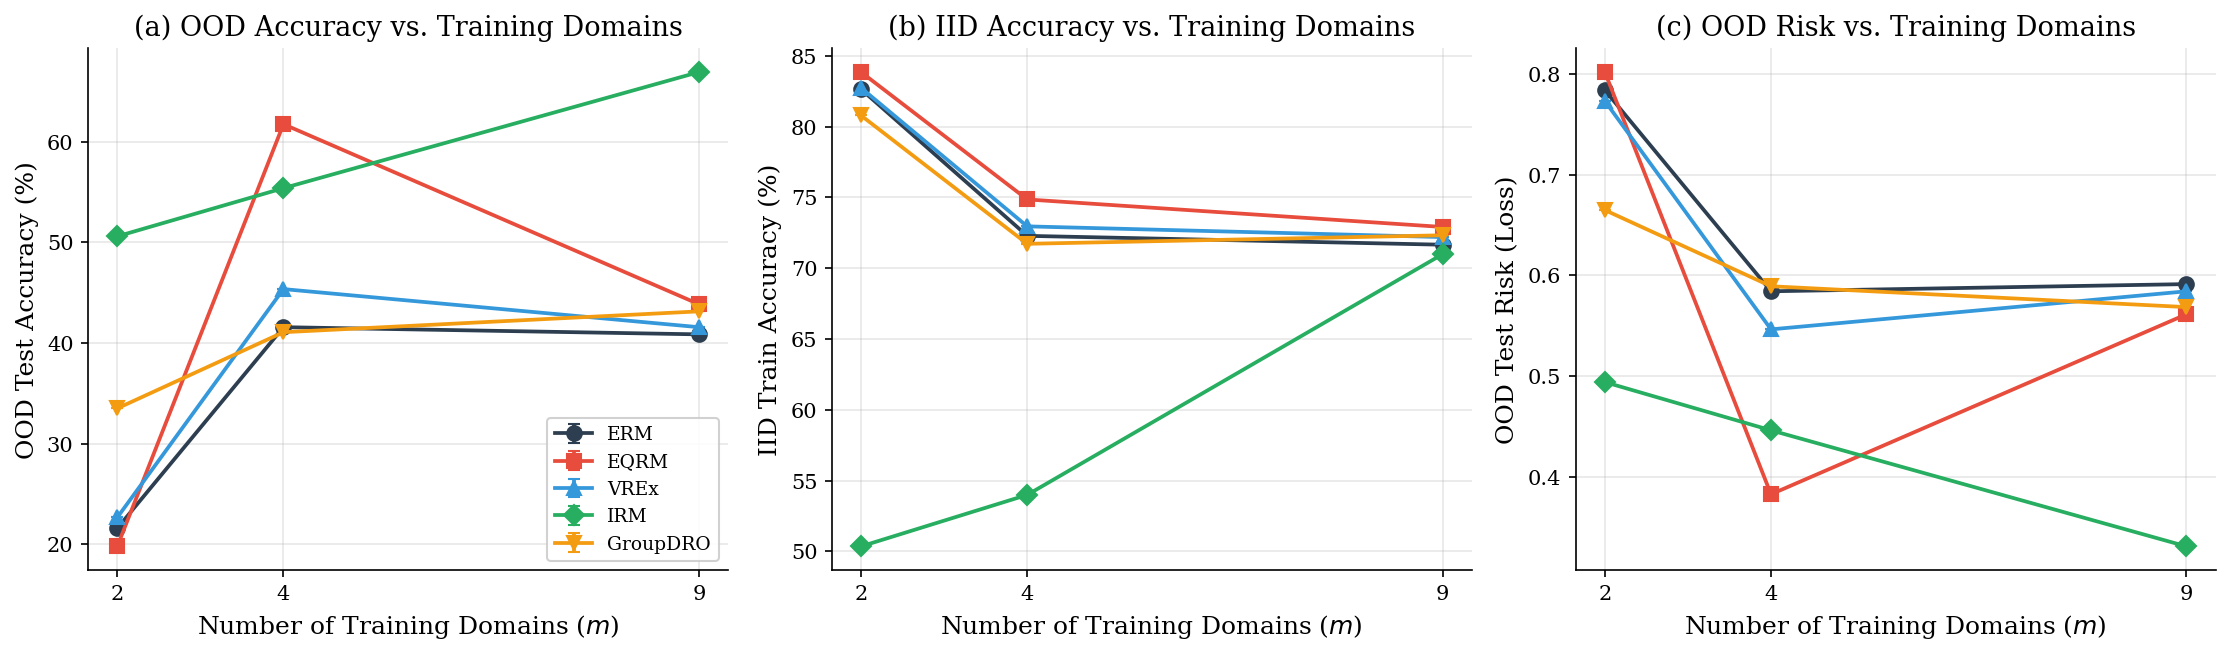

Saved fig1_cmnist_domain_scaling


In [10]:
# Filter to ColoredMNIST variants
cmnist_datasets = ['ColoredMNIST', 'ColoredMNIST5', 'ColoredMNIST10', 'ColoredMNIST20']
n_train_map = {'ColoredMNIST': 2, 'ColoredMNIST5': 4, 'ColoredMNIST10': 9, 'ColoredMNIST20': 19}

df_cmnist = df_agg[df_agg['dataset'].isin(cmnist_datasets)].copy()
df_cmnist['n_train_domains'] = df_cmnist['dataset'].map(n_train_map)

if len(df_cmnist) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # --- Panel 1: OOD accuracy ---
    ax = axes[0]
    for algo in ['ERM', 'EQRM', 'VREx', 'IRM', 'GroupDRO']:
        sub = df_cmnist[df_cmnist['algorithm'] == algo].sort_values('n_train_domains')
        if len(sub) == 0:
            continue
        ax.errorbar(
            sub['n_train_domains'], sub['test_acc_avg'] * 100,
            yerr=sub['test_acc_se'].fillna(0) * 100,
            marker=ALGO_MARKERS.get(algo, 'o'), color=ALGO_COLORS.get(algo, 'gray'),
            label=algo, linewidth=1.8, markersize=7, capsize=3,
        )
    ax.set_xlabel('Number of Training Domains ($m$)')
    ax.set_ylabel('OOD Test Accuracy (%)')
    ax.set_title('(a) OOD Accuracy vs. Training Domains')
    ax.legend(framealpha=0.9)
    ax.set_xticks([2, 4, 9])

    # --- Panel 2: IID (train) accuracy ---
    ax = axes[1]
    for algo in ['ERM', 'EQRM', 'VREx', 'IRM', 'GroupDRO']:
        sub = df_cmnist[df_cmnist['algorithm'] == algo].sort_values('n_train_domains')
        if len(sub) == 0:
            continue
        ax.errorbar(
            sub['n_train_domains'], sub['train_acc_avg'] * 100,
            yerr=sub['train_acc_se'].fillna(0) * 100,
            marker=ALGO_MARKERS.get(algo, 'o'), color=ALGO_COLORS.get(algo, 'gray'),
            label=algo, linewidth=1.8, markersize=7, capsize=3,
        )
    ax.set_xlabel('Number of Training Domains ($m$)')
    ax.set_ylabel('IID Train Accuracy (%)')
    ax.set_title('(b) IID Accuracy vs. Training Domains')
    ax.set_xticks([2, 4, 9])

    # --- Panel 3: OOD risk (loss) ---
    ax = axes[2]
    for algo in ['ERM', 'EQRM', 'VREx', 'IRM', 'GroupDRO']:
        sub = df_cmnist[df_cmnist['algorithm'] == algo].sort_values('n_train_domains')
        if len(sub) == 0:
            continue
        ax.errorbar(
            sub['n_train_domains'], sub['test_loss_avg'],
            yerr=sub['test_loss_se'].fillna(0),
            marker=ALGO_MARKERS.get(algo, 'o'), color=ALGO_COLORS.get(algo, 'gray'),
            label=algo, linewidth=1.8, markersize=7, capsize=3,
        )
    ax.set_xlabel('Number of Training Domains ($m$)')
    ax.set_ylabel('OOD Test Risk (Loss)')
    ax.set_title('(c) OOD Risk vs. Training Domains')
    ax.set_xticks([2, 4, 9])

    plt.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, 'fig1_cmnist_domain_scaling.pdf'))
    fig.savefig(os.path.join(PLOT_DIR, 'fig1_cmnist_domain_scaling.png'))
    plt.show()
    print("Saved fig1_cmnist_domain_scaling")
else:
    print("No ColoredMNIST results found. Run Block A first.")

### Plot 2: RotatedMNIST — Per-Domain Accuracy Heatmap

In [ ]:
# For RotatedMNIST12, show per-domain accuracy for each algorithm
rot_datasets = ['RotatedMNIST', 'RotatedMNIST12', 'RotatedMNIST18']
df_rot = df_best[df_best['dataset'].isin(rot_datasets)].copy()

if len(df_rot) > 0:
    # Pick the dataset with the most data
    for ds_name in ['RotatedMNIST12', 'RotatedMNIST18', 'RotatedMNIST']:
        ds_df = df_rot[df_rot['dataset'] == ds_name]
        if len(ds_df) > 0:
            target_ds = ds_name
            break

    ds_df = df_rot[df_rot['dataset'] == target_ds]
    ds_class = datasets.get_dataset_class(target_ds)
    env_names = ds_class.ENVIRONMENTS

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Panel 1: Per-domain accuracy across algorithms ---
    ax = axes[0]
    for algo in ['ERM', 'EQRM', 'VREx', 'GroupDRO']:
        algo_df = ds_df[ds_df['algorithm'] == algo]
        if len(algo_df) == 0:
            continue

        # Average per-env accuracy across trials and test_envs
        all_accs = {}
        for _, row in algo_df.iterrows():
            for env_idx, acc in row['all_env_accs'].items():
                env_idx = int(env_idx)
                if env_idx not in all_accs:
                    all_accs[env_idx] = []
                all_accs[env_idx].append(acc)

        env_indices = sorted(all_accs.keys())
        mean_accs = [np.mean(all_accs[e]) * 100 for e in env_indices]
        angles = [int(env_names[e]) if e < len(env_names) else e * 15
                  for e in env_indices]

        ax.plot(angles, mean_accs,
                marker=ALGO_MARKERS.get(algo, 'o'),
                color=ALGO_COLORS.get(algo, 'gray'),
                label=algo, linewidth=1.5, markersize=5)

    ax.set_xlabel('Rotation Angle (degrees)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'(a) Per-Domain Accuracy — {target_ds}')
    ax.legend(framealpha=0.9)

    # --- Panel 2: Per-domain risk (loss) ---
    ax = axes[1]
    for algo in ['ERM', 'EQRM', 'VREx', 'GroupDRO']:
        algo_df = ds_df[ds_df['algorithm'] == algo]
        if len(algo_df) == 0:
            continue

        all_losses = {}
        for _, row in algo_df.iterrows():
            for env_idx, loss in row['all_env_losses'].items():
                env_idx = int(env_idx)
                if env_idx not in all_losses:
                    all_losses[env_idx] = []
                all_losses[env_idx].append(loss)

        env_indices = sorted(all_losses.keys())
        mean_losses = [np.mean(all_losses[e]) for e in env_indices]
        angles = [int(env_names[e]) if e < len(env_names) else e * 15
                  for e in env_indices]

        ax.plot(angles, mean_losses,
                marker=ALGO_MARKERS.get(algo, 'o'),
                color=ALGO_COLORS.get(algo, 'gray'),
                label=algo, linewidth=1.5, markersize=5)

    ax.set_xlabel('Rotation Angle (degrees)')
    ax.set_ylabel('Risk (Loss)')
    ax.set_title(f'(b) Per-Domain Risk — {target_ds}')
    ax.legend(framealpha=0.9)

    plt.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, 'fig2_rotated_mnist_per_domain.pdf'))
    fig.savefig(os.path.join(PLOT_DIR, 'fig2_rotated_mnist_per_domain.png'))
    plt.show()
    print("Saved fig2_rotated_mnist_per_domain")
else:
    print("No RotatedMNIST results found. Run Block B first.")

### Plot 3: Risk Distribution Comparison (extends Fig. 4 of the paper)

KDE-smoothed distribution of per-domain risks, comparing ERM vs EQRM.

In [ ]:
from scipy.stats import gaussian_kde

def plot_risk_distributions(df_best, dataset_name, plot_dir, figname):
    """Plot KDE-smoothed risk distributions for each algorithm.
    Mirrors Figure 4 of the EQRM paper."""

    ds_df = df_best[df_best['dataset'] == dataset_name]
    if len(ds_df) == 0:
        print(f"No data for {dataset_name}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Collect ALL per-env risks for each algorithm
    for algo in ['ERM', 'EQRM', 'VREx', 'GroupDRO']:
        algo_df = ds_df[ds_df['algorithm'] == algo]
        if len(algo_df) == 0:
            continue

        # Gather all per-env losses across trials
        all_losses = []
        all_accs = []
        for _, row in algo_df.iterrows():
            all_losses.extend(row['train_losses_list'])
            all_accs.extend(row['train_accs_list'])

        if len(all_losses) < 3:
            continue

        color = ALGO_COLORS.get(algo, 'gray')

        # Risk distribution (loss)
        try:
            kde = gaussian_kde(all_losses, bw_method='silverman')
            x_range = np.linspace(min(all_losses) - 0.1, max(all_losses) + 0.1, 200)
            axes[0].plot(x_range, kde(x_range), color=color, label=algo,
                         linewidth=2)
            axes[0].fill_between(x_range, kde(x_range), alpha=0.15, color=color)
        except Exception:
            axes[0].hist(all_losses, bins=15, alpha=0.3, color=color,
                         label=algo, density=True)

        # Accuracy distribution
        try:
            kde_acc = gaussian_kde(all_accs, bw_method='silverman')
            x_range_acc = np.linspace(
                max(0, min(all_accs) - 0.05),
                min(1, max(all_accs) + 0.05), 200)
            axes[1].plot(x_range_acc, kde_acc(x_range_acc), color=color,
                         label=algo, linewidth=2)
            axes[1].fill_between(x_range_acc, kde_acc(x_range_acc),
                                 alpha=0.15, color=color)
        except Exception:
            axes[1].hist(all_accs, bins=15, alpha=0.3, color=color,
                         label=algo, density=True)

    axes[0].set_xlabel('Risk (Loss)')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'(a) Risk Distribution — {dataset_name}')
    axes[0].legend(framealpha=0.9)

    axes[1].set_xlabel('Accuracy')
    axes[1].set_ylabel('Density')
    axes[1].set_title(f'(b) Accuracy Distribution — {dataset_name}')
    axes[1].legend(framealpha=0.9)

    plt.tight_layout()
    fig.savefig(os.path.join(plot_dir, f'{figname}.pdf'))
    fig.savefig(os.path.join(plot_dir, f'{figname}.png'))
    plt.show()
    print(f"Saved {figname}")


# Plot for each RotatedMNIST variant
for ds in ['RotatedMNIST12', 'RotatedMNIST18', 'RotatedMNIST']:
    if ds in df_best['dataset'].values:
        plot_risk_distributions(df_best, ds, PLOT_DIR,
                                f'fig3_risk_dist_{ds}')

### Plot 4: MNIST vs FashionMNIST Comparison (Block C)

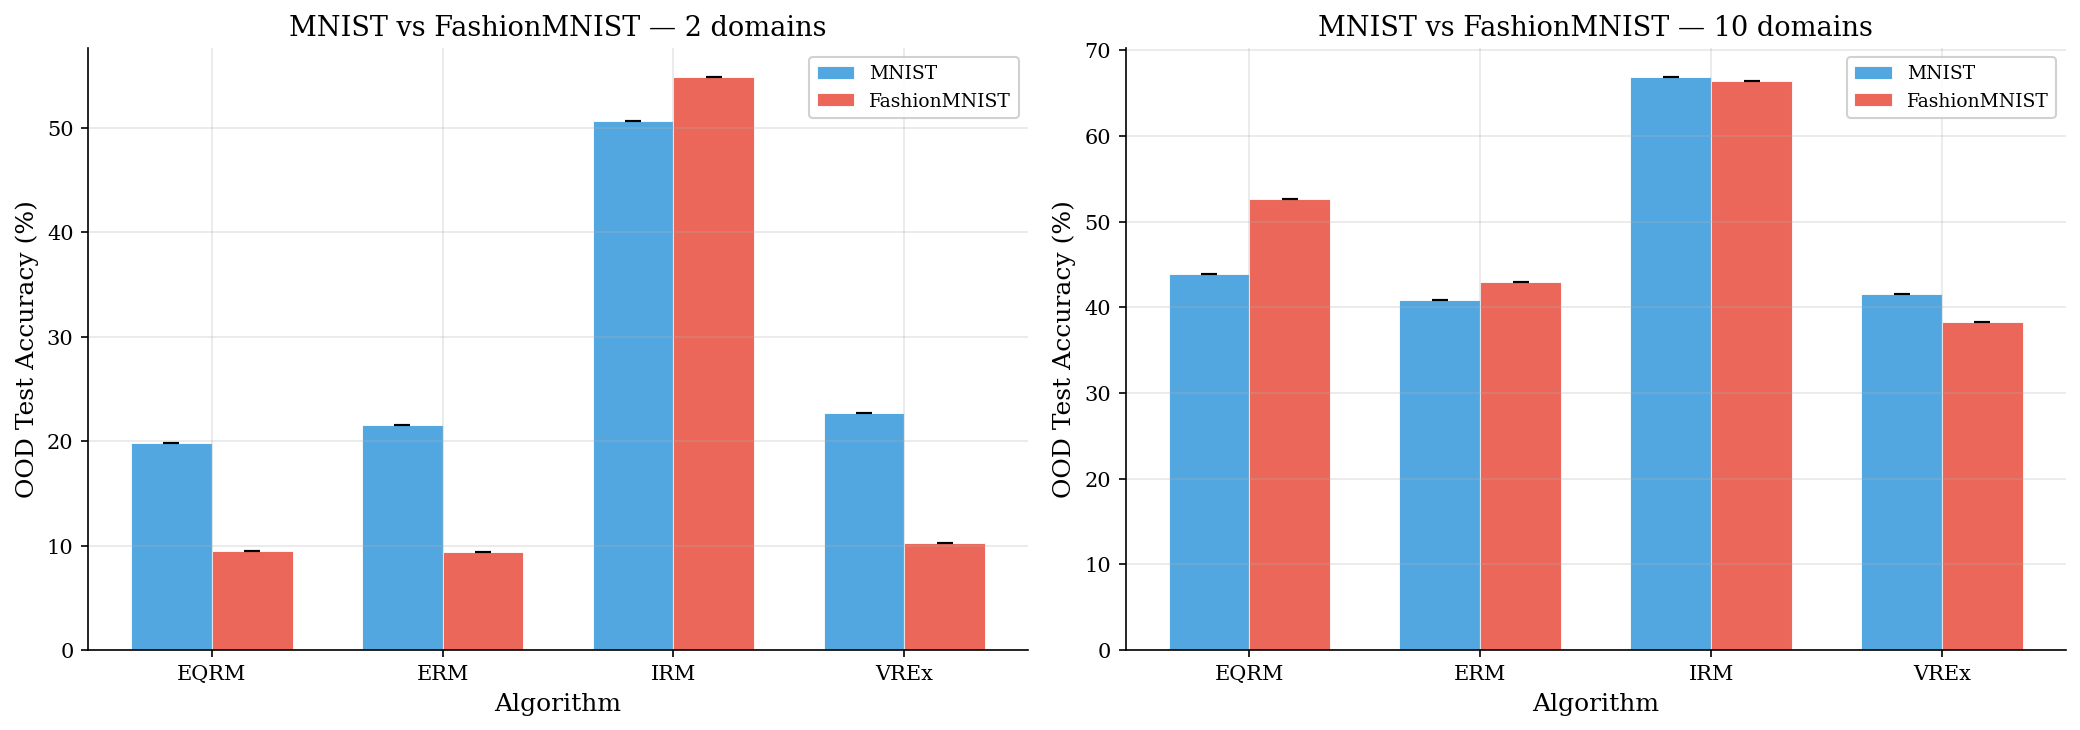

Saved fig4_mnist_vs_fashion


In [11]:
fashion_datasets = [
    ('ColoredMNIST', 'ColoredFashionMNIST', '2 domains'),
    ('ColoredMNIST10', 'ColoredFashionMNIST10', '10 domains'),
]

# Check which pairs we have data for
available_pairs = [
    (m, f, label) for m, f, label in fashion_datasets
    if m in df_agg['dataset'].values and f in df_agg['dataset'].values
]

if available_pairs:
    fig, axes = plt.subplots(1, len(available_pairs), figsize=(7 * len(available_pairs), 5))
    if len(available_pairs) == 1:
        axes = [axes]

    for idx, (mnist_ds, fashion_ds, pair_label) in enumerate(available_pairs):
        ax = axes[idx]

        algos_present = sorted(
            set(df_agg[df_agg['dataset'] == mnist_ds]['algorithm'].tolist()) &
            set(df_agg[df_agg['dataset'] == fashion_ds]['algorithm'].tolist())
        )

        x = np.arange(len(algos_present))
        width = 0.35

        mnist_accs = []
        fashion_accs = []
        mnist_errs = []
        fashion_errs = []

        for algo in algos_present:
            m_row = df_agg[(df_agg['dataset'] == mnist_ds) &
                           (df_agg['algorithm'] == algo)]
            f_row = df_agg[(df_agg['dataset'] == fashion_ds) &
                           (df_agg['algorithm'] == algo)]

            mnist_accs.append(m_row['test_acc_avg'].values[0] * 100 if len(m_row) else 0)
            fashion_accs.append(f_row['test_acc_avg'].values[0] * 100 if len(f_row) else 0)
            mnist_errs.append(m_row['test_acc_se'].fillna(0).values[0] * 100 if len(m_row) else 0)
            fashion_errs.append(f_row['test_acc_se'].fillna(0).values[0] * 100 if len(f_row) else 0)

        bars1 = ax.bar(x - width/2, mnist_accs, width, yerr=mnist_errs,
                        label='MNIST', color='#3498db', alpha=0.85,
                        capsize=4, edgecolor='white', linewidth=0.5)
        bars2 = ax.bar(x + width/2, fashion_accs, width, yerr=fashion_errs,
                        label='FashionMNIST', color='#e74c3c', alpha=0.85,
                        capsize=4, edgecolor='white', linewidth=0.5)

        ax.set_xlabel('Algorithm')
        ax.set_ylabel('OOD Test Accuracy (%)')
        ax.set_title(f'MNIST vs FashionMNIST — {pair_label}')
        ax.set_xticks(x)
        ax.set_xticklabels(algos_present)
        ax.legend(framealpha=0.9)
        ax.set_ylim(bottom=0)

    plt.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, 'fig4_mnist_vs_fashion.pdf'))
    fig.savefig(os.path.join(PLOT_DIR, 'fig4_mnist_vs_fashion.png'))
    plt.show()
    print("Saved fig4_mnist_vs_fashion")
else:
    print("No MNIST/FashionMNIST comparison data. Run Block C first.")

### Plot 5: IID vs OOD Gap Analysis

In [ ]:
# Scatter plot: IID accuracy vs OOD accuracy for each algorithm
# across all datasets — reveals which algorithms degrade most under shift

if len(df_agg) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))

    for algo in df_agg['algorithm'].unique():
        sub = df_agg[df_agg['algorithm'] == algo]
        ax.scatter(
            sub['train_acc_avg'] * 100,
            sub['test_acc_avg'] * 100,
            c=ALGO_COLORS.get(algo, 'gray'),
            marker=ALGO_MARKERS.get(algo, 'o'),
            s=60, label=algo, alpha=0.8, edgecolors='white', linewidth=0.5,
        )

    # Diagonal line (no gap)
    lims = [0, 100]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1, label='IID = OOD')

    ax.set_xlabel('IID Train Accuracy (%)')
    ax.set_ylabel('OOD Test Accuracy (%)')
    ax.set_title('IID vs OOD Performance Gap')
    ax.legend(framealpha=0.9, loc='lower right')
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, 'fig5_iid_vs_ood_gap.pdf'))
    fig.savefig(os.path.join(PLOT_DIR, 'fig5_iid_vs_ood_gap.png'))
    plt.show()
    print("Saved fig5_iid_vs_ood_gap")
else:
    print("No results to plot.")

### Plot 6: Train-Domain Risk Variance (Invariance Measure)

EQRM with α→1 should minimize variance of risk across domains (Prop 4.3).
We plot the standard deviation of train-domain losses as a proxy for risk invariance.

In [ ]:
# Compute risk variance for each run
if 'train_loss_std' in df_agg.columns and len(df_agg) > 0:

    # Group by dataset family for cleaner plots
    colored_ds = [d for d in df_agg['dataset'].unique()
                  if 'Colored' in d and 'Fashion' not in d]

    if colored_ds:
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))

        ds_order = sorted(colored_ds,
                          key=lambda x: n_train_map.get(x, 99))

        x = np.arange(len(ds_order))
        n_algos = len(df_agg['algorithm'].unique())
        width = 0.8 / n_algos

        for i, algo in enumerate(sorted(df_agg['algorithm'].unique())):
            vals = []
            for ds in ds_order:
                row = df_agg[(df_agg['dataset'] == ds) &
                             (df_agg['algorithm'] == algo)]
                vals.append(row['train_loss_se'].values[0] if len(row) else 0)

            ax.bar(x + i * width - 0.4 + width/2, vals, width,
                   label=algo if x[0] == 0 else '',
                   color=ALGO_COLORS.get(algo, 'gray'),
                   alpha=0.85, edgecolor='white', linewidth=0.5)

        ax.set_xlabel('Dataset')
        ax.set_ylabel('Std. Dev. of Train-Domain Risks')
        ax.set_title('Risk Invariance Across Training Domains\n'
                     '(lower = more invariant, EQRM α→1 should minimize this)')
        ax.set_xticks(x)
        ax.set_xticklabels([f"{ds}\n(m={n_train_map.get(ds, '?')})"
                            for ds in ds_order], fontsize=9)
        ax.legend(framealpha=0.9)

        plt.tight_layout()
        fig.savefig(os.path.join(PLOT_DIR, 'fig6_risk_invariance.pdf'))
        fig.savefig(os.path.join(PLOT_DIR, 'fig6_risk_invariance.png'))
        plt.show()
        print("Saved fig6_risk_invariance")
else:
    print("No variance data available.")

## 8. Summary Tables

In [12]:
# Generate LaTeX-style summary tables

def format_acc(mean, se):
    """Format accuracy as 'XX.X ± Y.Y'"""
    if pd.isna(mean):
        return '—'
    if pd.isna(se) or se == 0:
        return f'{mean*100:.1f}'
    return f'{mean*100:.1f} ± {se*100:.1f}'


print("=" * 80)
print("TABLE 1: ColoredMNIST Domain Scaling — OOD Test Accuracy (%)")
print("=" * 80)

for ds in ['ColoredMNIST', 'ColoredMNIST5', 'ColoredMNIST10', 'ColoredMNIST20']:
    sub = df_agg[df_agg['dataset'] == ds]
    if len(sub) == 0:
        continue
    m = n_train_map.get(ds, '?')
    print(f"\n{ds} (m={m}):")
    for _, row in sub.iterrows():
        print(f"  {row['algorithm']:12s}  "
              f"OOD: {format_acc(row['test_acc_avg'], row['test_acc_se']):>12s}  "
              f"IID: {format_acc(row['train_acc_avg'], row['train_acc_se']):>12s}  "
              f"Risk: {row['test_loss_avg']:.4f}")

print("\n")
print("=" * 80)
print("TABLE 2: RotatedMNIST — Average Accuracy (%)")
print("=" * 80)

for ds in ['RotatedMNIST', 'RotatedMNIST12', 'RotatedMNIST18']:
    sub = df_agg[df_agg['dataset'] == ds]
    if len(sub) == 0:
        continue
    print(f"\n{ds}:")
    for _, row in sub.iterrows():
        print(f"  {row['algorithm']:12s}  test_env={row['test_envs']:>6s}  "
              f"OOD: {format_acc(row['test_acc_avg'], row['test_acc_se']):>12s}  "
              f"IID: {format_acc(row['train_acc_avg'], row['train_acc_se']):>12s}")

print("\n")
print("=" * 80)
print("TABLE 3: MNIST vs FashionMNIST — OOD Test Accuracy (%)")
print("=" * 80)

for ds in ['ColoredMNIST', 'ColoredFashionMNIST', 'ColoredMNIST10', 'ColoredFashionMNIST10']:
    sub = df_agg[df_agg['dataset'] == ds]
    if len(sub) == 0:
        continue
    print(f"\n{ds}:")
    for _, row in sub.iterrows():
        print(f"  {row['algorithm']:12s}  "
              f"OOD: {format_acc(row['test_acc_avg'], row['test_acc_se']):>12s}  "
              f"IID: {format_acc(row['train_acc_avg'], row['train_acc_se']):>12s}")

TABLE 1: ColoredMNIST Domain Scaling — OOD Test Accuracy (%)

ColoredMNIST (m=2):
  EQRM          OOD:         19.8  IID:         83.9  Risk: 0.8022
  ERM           OOD:         21.6  IID:         82.6  Risk: 0.7842
  GroupDRO      OOD:         33.5  IID:         80.8  Risk: 0.6650
  IRM           OOD:         50.6  IID:         50.4  Risk: 0.4940
  VREx          OOD:         22.7  IID:         82.7  Risk: 0.7735

ColoredMNIST5 (m=4):
  EQRM          OOD:         61.8  IID:         74.9  Risk: 0.3825
  ERM           OOD:         41.6  IID:         72.3  Risk: 0.5843
  GroupDRO      OOD:         41.1  IID:         71.7  Risk: 0.5893
  IRM           OOD:         55.4  IID:         54.0  Risk: 0.4461
  VREx          OOD:         45.4  IID:         73.0  Risk: 0.5464

ColoredMNIST10 (m=9):
  EQRM          OOD:         43.9  IID:         72.9  Risk: 0.5614
  ERM           OOD:         40.9  IID:         71.7  Risk: 0.5914
  GroupDRO      OOD:         43.1  IID:         72.3  Risk: 0.5686
  

## 9. Save Everything

In [ ]:
# List all saved files
print("Files saved to Google Drive:")
print(f"  Results dir: {RESULTS_DIR}")
print()

for root_dir, dirs, files in os.walk(RESULTS_DIR):
    # Skip 'raw' subdirectories listing (too many)
    if 'raw' in root_dir and root_dir != os.path.join(RESULTS_DIR, 'raw'):
        continue
    level = root_dir.replace(RESULTS_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    subdir_name = os.path.basename(root_dir)
    if subdir_name == 'raw':
        n_subdirs = len([d for d in dirs])
        print(f"{indent}{subdir_name}/ ({n_subdirs} experiment runs)")
        continue
    print(f"{indent}{subdir_name}/")
    subindent = ' ' * 2 * (level + 1)
    for file in sorted(files):
        filepath = os.path.join(root_dir, file)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"{subindent}{file} ({size_kb:.1f} KB)")

print("\nDone! All results and plots saved to Google Drive.")

In [ ]:
import time
print("All experiments complete. Results saved to Drive.")
print("Disconnecting runtime in 60 seconds...")
print("(Interrupt this cell to cancel)")

time.sleep(60)

from google.colab import runtime
runtime.unassign()